## HW 4
### Choosing our Dataset
We are classifying mushrooms -- poisonous or not! Our data set has 22 features for 8124 entries, with the first feature being our targeted 'is it poisonous' feature.

In [94]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd;
  
# fetch dataset 
mushroom = fetch_ucirepo(id=73) 
  
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 
  
# metadata 
print(mushroom.metadata) 
  
# variable information 
print(mushroom.variables) 


{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

### Pre-processing the data
Feature 11 is missing close to 1/3rd of its values. It would be reasonable to drop the feature because it is so incomplete, but I will instead choose to preserve it, replacing missing values with the 'missing' category, in case there is a meaningful signal in that data.

Then we one-hot encode our 22 categorical features into 95 true/false features. This is standard but I'll explain it for my own benefit and the homework's: we used one-hot encoding, which 'drops' categorizations that are now implicitly present in the data set (e.g. when cap-shape is not conical, convex, or any other represented shape it is the dropped cap-shape 'bell').

For KNN and SVM scaling data is standard but all of our data is binary, thus already on the same scale.

In [95]:
X["stalk-root"] = X["stalk-root"].fillna('missing')
X_encoded = pd.get_dummies(X, drop_first = True)

y_encoded = y['poisonous'].map({'e': 0, 'p': 1}) #Edible to 0, Poisonous to 1

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2, #80/20
    random_state=13, #setting random seed for reproducibility
    stratify=y #match poisonous/non-poisonous distribution across train and test
)

### Training and evaluating our models
##### Logistic Regression

In [96]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=1000, random_state=13)
logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall:", recall_score(y_test, y_pred_logreg))
print("F1:", f1_score(y_test, y_pred_logreg))

# or get all of them at once, broken out by class
print(classification_report(y_test, y_pred_logreg, target_names=['edible', 'poisonous']))

#Sanity checking because we got perfect predictions...
# print('poisonous' in X_encoded.columns) #Did we accidetally leave our target in X?
# print(X_encoded.columns)

print(confusion_matrix(y_test, y_pred_logreg))

coef_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': logreg.coef_[0],
    'count_true': X_encoded.sum().values #added to determine how prevalent high-coefficient features are in the dataset
})

coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df_sorted = coef_df.sort_values('abs_coef', ascending=False)

print(coef_df_sorted.head(60))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

[[842   0]
 [  0 783]]
                       feature  coefficient  count_true  abs_coef
80         spore-print-color_r     4.714185          72  4.714185
18                      odor_c     3.959306         192  3.959306
22                      odor_n    -3.922474        3528  3.922474
28                 gill-size_n     3.484096        2512  3.484096
19                      odor_f     3.467432        2160  3.467432
23                      odor_p     2.743404         256  2.743404
27              gill-spacing_w    -2.575962        1312  2.575962
78         spore-print-color_n    -2.187503        1968  2.187503
41     

*Evaluation*:
The biggest surprise here is that this model is perfectly categorizing our training data. With this much data and a task that boils down to distinguishing the species of a fungus, it is within the realm of possibility that perfect classification is possible. 

How is logistic regression making these distinctions? 
Our top coefficient was that mushrooms with a black spore print were poisonous, but this was a rare predictor covering only 72 entries in our dataset.

Disregarding that predictor, our two strongest predictors were *odor* and *gill-size*. Nearly half of our data-set had no odor and was not poisonous. Another 2160 entries in our sample that smelled 'foul' were, unsurprisingly, strongly correlated with a 'poisonous' classficiation. Another three odors across 1024 samples ('creosote', 'pungent', and 'spicy') correlated with poisonous classification, and 400 entries with the 'anise' odor strongly correlated with edibility. 'Narrow' gill-size, as opposed to 'broad', strongly correlated with poisonous mushrooms. 

These features did not dominate our analysis: over half our features had a meaningful signaling effect, with coefficents not dipping below 10% of 'odor_c's 3.96 coefficient until the 58th sorted entry (gill-attachment_f at a coefficient of 0.45).

##### KNN

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



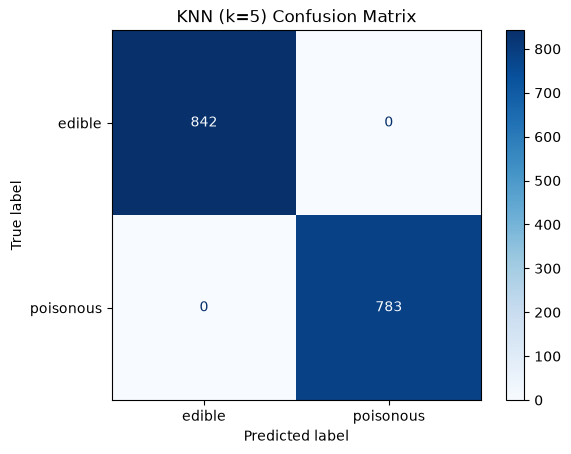

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Exploring k-values - 
# 5 worked best (1 - 12 were all fully accurate) and we stick with it down below
#
# k_values = [5, 15, 50, 80] 
# knn_results = []

# for k in k_values:
#     knn = KNeighborsClassifier(n_neighbors=k)
#     knn.fit(X_train, y_train)
#     y_pred = knn.predict(X_test)
    
#     knn_results.append({
#         'k': k,
#         'accuracy': accuracy_score(y_test, y_pred),
#         'precision': precision_score(y_test, y_pred),
#         'recall': recall_score(y_test, y_pred),
#         'f1': f1_score(y_test, y_pred)
#     })

# knn_results_df = pd.DataFrame(knn_results)
# print(knn_results_df)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(classification_report(y_test, y_pred_knn, target_names=['edible', 'poisonous']))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=['edible', 'poisonous'],
    cmap='Blues'
)
plt.title('KNN (k=5) Confusion Matrix')
plt.show()

KNN also successfully classifies our fungus with 100% accuracy. 

KNN does not give us as clear an interpretation as logistic regration with its rankable class coefficients, but we can use k to describe the grouping of our datapoints. K-values 1 - 12 all gave us perfect accuracy, decreasing with higher k values. What this suggests is that our features are distinctly grouping the data without overlap or outliers, enough, even with a k = 1, every point in our test data that we looked at ended up nearest to a correctly matching and classified point in the data. 

### Decision Tree

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



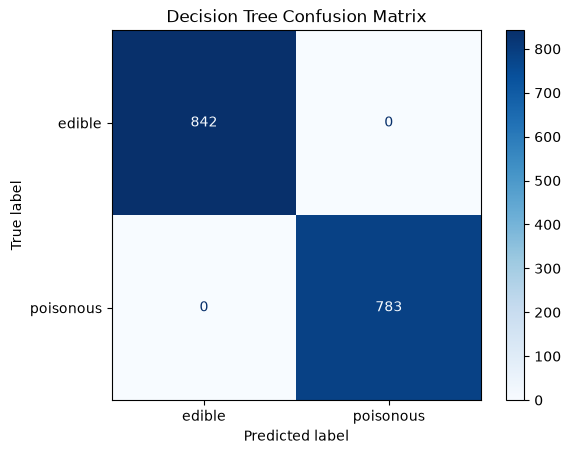

In [98]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=13)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print(classification_report(y_test, y_pred_tree, target_names=['edible', 'poisonous']))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tree,
    display_labels=['edible', 'poisonous'],
    cmap='Blues'
)
plt.title('Decision Tree Confusion Matrix')
plt.show()

Unsurprisingly given our last two models, Decision tree also perfectly predicts test data. Alas, we seem to have very complete data for a very tractable problem. 

Decision Tree diverges from our model in interesting ways when it comes to interpretability.

In [101]:
importances_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

print(importances_df.head(15))

                       feature  importance
22                      odor_n    0.616410
41                stalk-root_c    0.181607
50  stalk-surface-below-ring_y    0.094958
80         spore-print-color_r    0.036327
17                   bruises_t    0.022955
27              gill-spacing_w    0.022139
46  stalk-surface-above-ring_s    0.016167
28                 gill-size_n    0.005782
84                population_c    0.001812
5                cap-surface_g    0.001228
0                  cap-shape_c    0.000615
85                population_n    0.000000
86                population_s    0.000000
67                veil-color_o    0.000000
66    stalk-color-below-ring_y    0.000000


Our decision tree model was able to fully identify poisonous fungi with only 11 features. There were some surprising absent features in these top 11 - odors besides 'n' and colors besides 'b' do not appear. For odor, this suggests that the most imporant information is simply whether or not the odor is 'n' (none) and any presence of a smell suggests a classification. We know from our logistic regression model that odorlessness suggests the fungus is not poisonous.

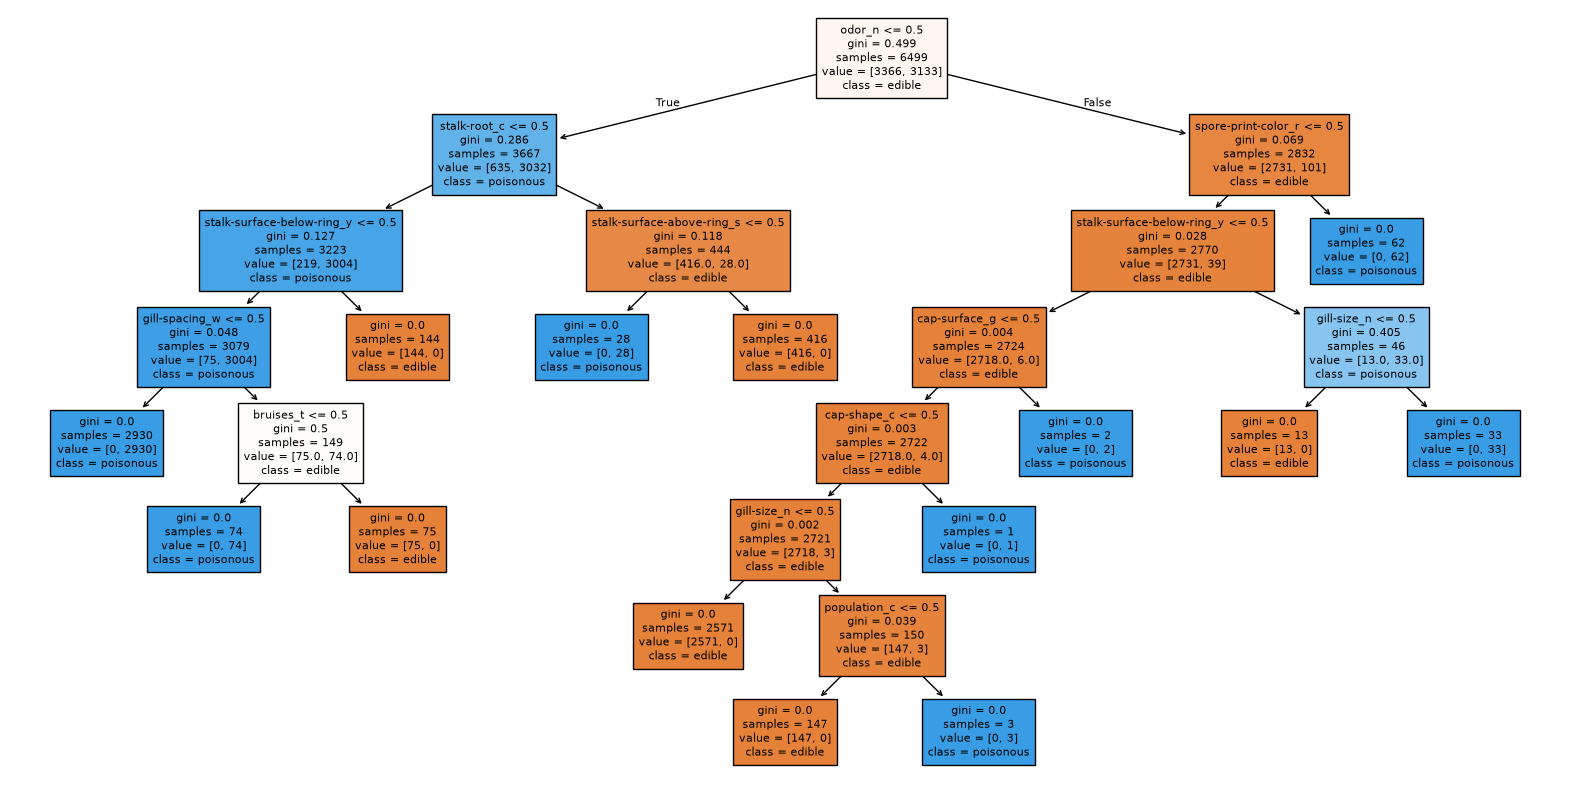

In [102]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=X_encoded.columns, class_names=['edible', 'poisonous'], filled=True, fontsize=8)
plt.show()

This visualization, to me, gives the clearest overview of our classified data. With previous models I had been curious about the strength of the 'no odor' predictor in determining whether a fungus as poisonous but didn't have a clear picture of it. This visual directly shows that for the odorless mushrooms, only 147 out of 2832 are poisonous, distinguished by the rare black spore print and narrow gill size principally (with 6 oddballs). A similar picture can be quickly arrived at for the fungi with odor.

### SVM

In [107]:
from sklearn.svm import SVC

# svm = SVC(kernel='rbf', random_state=13)
# svm.fit(X_train, y_train)

# y_pred_svm = svm.predict(X_test)

# print(classification_report(y_test, y_pred_svm, target_names=['edible', 'poisonous']))

# ConfusionMatrixDisplay.from_predictions(
#     y_test, y_pred_svm,
#     display_labels=['edible', 'poisonous'],
#     cmap='Blues'
# )
# plt.title('SVM Confusion Matrix')
# plt.show()

svm_linear = SVC(kernel='linear', random_state=13)
svm_linear.fit(X_train, y_train)

y_pred_svm = svm_linear.predict(X_test)

print(classification_report(y_test, y_pred_svm, target_names=['edible', 'poisonous']))

coef_df_svm = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': svm_linear.coef_[0],
    'count_true': X_encoded.sum().values
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df_svm.head(15))

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

                       feature  coefficient  count_true
80         spore-print-color_r     2.163290          72
18                      odor_c     1.786048         192
28                 gill-size_n     1.044127        2512
19                      odor_f     0.999827        2160
23                      odor_p     0.949234         256
44                stalk-root_r    -0.927674         192
84                population_c     0.894885         340
22                      odor_n    -0.854290        3528
78         spore-print-color_n    -0.822260        1968
81         spore-print-color_u    -0.822184          48
77         spore-print-color_k    -0.822179        1872
4

As with the other models, SVM is able to perfectly predict our test data. Using a linear SVM with extractable coefficients, we see a similar ranking compared to our logistic regression. Like with logistic regression, spore-print-color_r (black) is at the top of the list but describes a small part of the data. One surprising difference is the lower rating and coefficient of 'odor_n' which was possibly the most important feature when considering coefficient along with relevant samples for Logistic Regression and Decision Tree. This suggests that, for SVM's goal of maximizing separation margins, odor_n may be less imporant.

Logistic Regression's coefficient list, for reference:
"""

80         spore-print-color_r     4.714185          72  
18                      odor_c     3.959306         192  
22                      odor_n    -3.922474        3528  
28                 gill-size_n     3.484096        2512  
19                      odor_f     3.467432        2160  
23                      odor_p     2.743404         256  
27              gill-spacing_w    -2.575962        1312  
78         spore-print-color_n    -2.187503        1968  
41                stalk-root_c    -2.146822         556  

"""

## Model Comparison and Reflection

All four of our models were equally effective becasue they were completely effective. I didn't realize when I picked this dataset that it had a known history and known drawbacks. It was donated to the UCI Machine  Learning Repository in 1987, is widely studied and known to be very 'clean' data, but is NOT recommended for making predictions for real-world foraging because the clean data does not match what exists in the wild. 

With perfect precision across our models, the area of comparison between models becomes interpretability. The decision tree model was able to minimize the number of meaningful features to separate our data and visualize it in a way that showed relative importance of features and how their decision affected the distribution of poisonous and edible mushrooms further down the tree. If I were to rank the models by utility...- Decision Tree would be first by a wide margin 
- logistic regression and SVM behind them in no particular order because their coefficient rankings tell a different story but I don't have a strong sense of which story is more useful. I might put logistic regression before SVM because its story matches what I'm getting from Decision Tree
- and finally KNN in last because I could only interpret intuition about the shape of the data (tight clusters that perfectly predict classification) but not insights into specific features.